### Notebook to generate the images and tables from the results in JSON format.
### Date: 2025/6/10
### Author: Hao Hu



In [1]:
### Target 1: Prepare the summary table of results comparing Boomer and XGBoost on multi-classification benchmarks

import numpy as np
import pandas as pd
import json

# read XGBoost and Boomer results in the JSON format
df_xgboost = pd.read_json('./result_xgboost.json')
df_boomer = pd.read_json('./result_boomer.json')
df_boomer_s = pd.read_json('./result_boomer_s.json')

datasets = sorted(set(df_xgboost['dataset']))
# print(datasets)

# print(df_xgboost.loc[df_xgboost['dataset'] == 'ann-thyroid'])



# for d in datasets:
#     rows_xgboost = df_xgboost[df_xgboost['dataset' == d]]

# df_xgboost.to_latex('tab_xgboost.tex')
# df_boomer.to_latex('tab_boomer.tex')

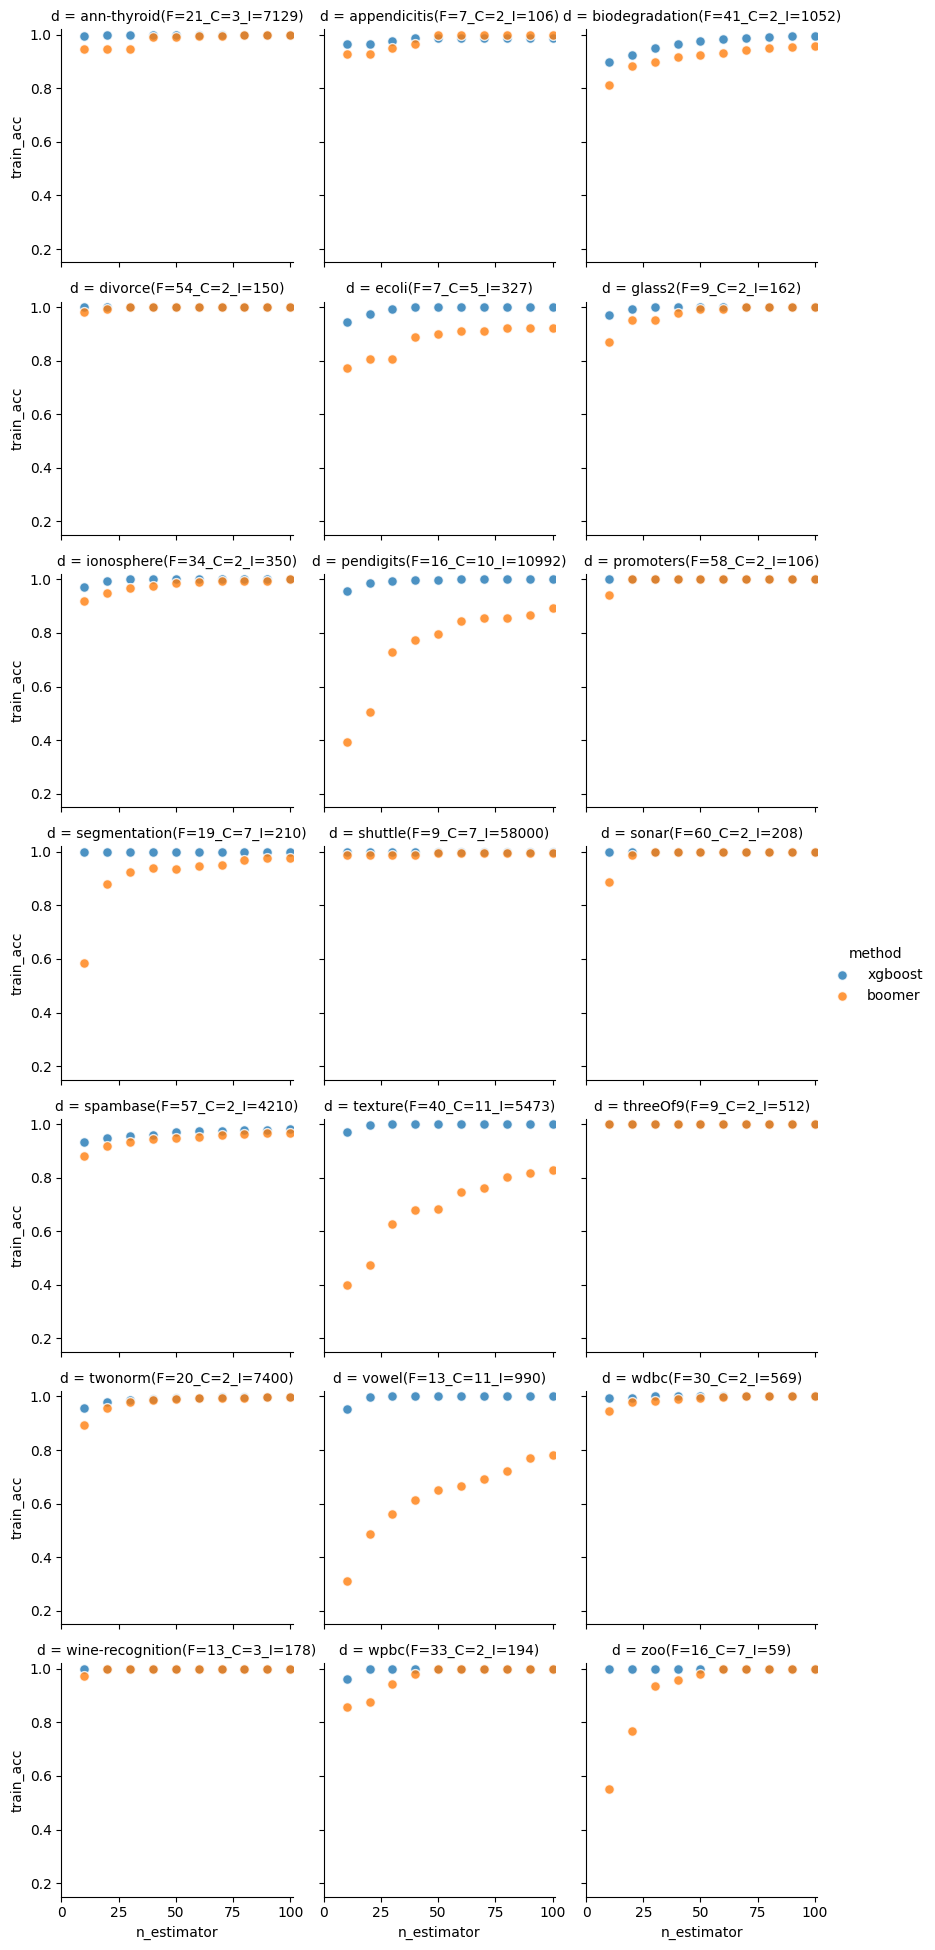

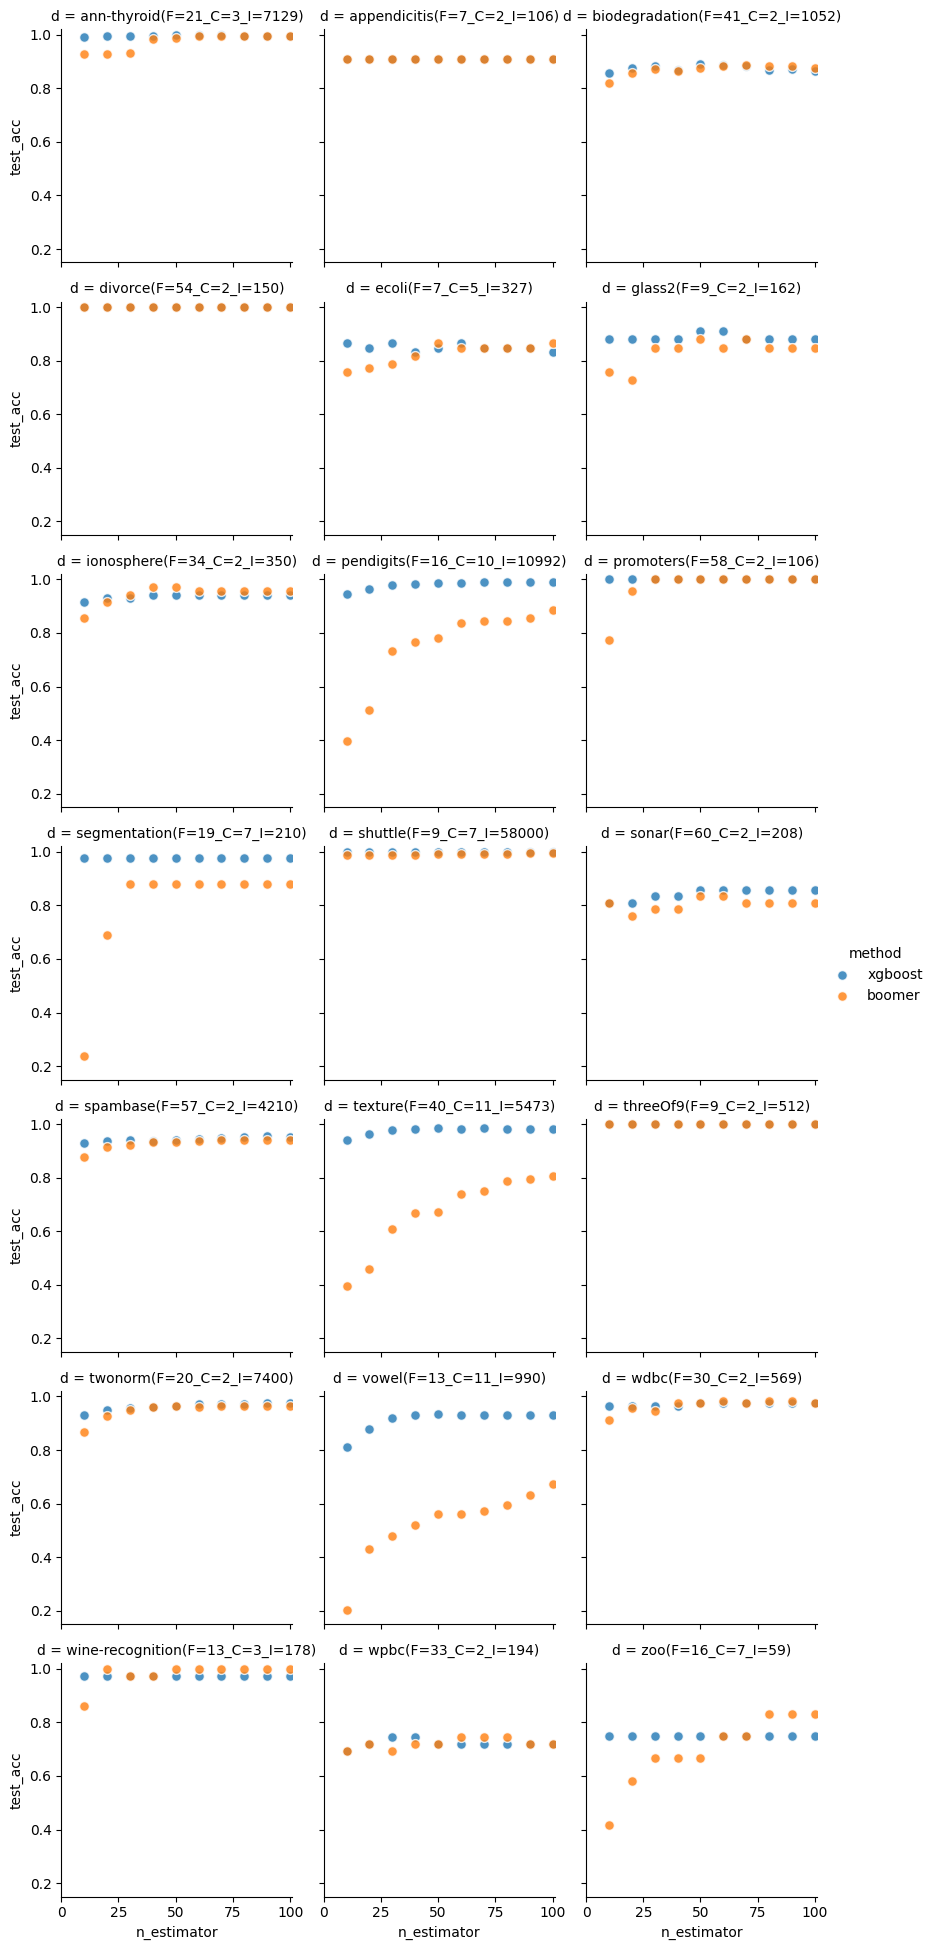

In [2]:
### Target 2: Prepare the line plots/ scatters to show the performance between Boomer and XGBoost of different conditions

import seaborn as sns
import matplotlib as plt

# add the column of method
df_xgboost['method'] = 'xgboost'
df_boomer['method'] = 'boomer'

# concat the two dataframe into one
df_xgboost_boomer = pd.concat([df_xgboost, df_boomer])


add_dataset_info = lambda r: r['dataset'] + '(F=' + str(r['num_feat']) + '_C=' + str(r['num_class']) + '_I=' + str(r['num_instance']) + ')'
df_xgboost_boomer['dataset'] = df_xgboost_boomer.apply(add_dataset_info, axis='columns')
df_xgboost_boomer.rename(columns={'dataset': 'd'}, inplace=True)


# The scatter for presenting all training accuracy categorized by dataset
g = sns.FacetGrid(df_xgboost_boomer, col='d', col_wrap=3, xlim=(0, 101), ylim=(0.15, 1.02), hue='method', height=2.8)
g.map(sns.scatterplot, 'n_estimator', 'train_acc', edgecolor="white", s=50, lw=1, alpha=.8)
g.add_legend()
g.savefig('./xgboost_boomer_train_acc.png')

# The scatter for presenting all testing accuracy categorized by dataset
g1 = sns.FacetGrid(df_xgboost_boomer, col='d', col_wrap=3, xlim=(0, 101), ylim=(0.15, 1.02), hue='method', height=2.8)
g1.map(sns.scatterplot, 'n_estimator', 'test_acc', edgecolor="white", s=50, lw=1, alpha=.8)
g1.add_legend()
g1.savefig('./xgboost_boomer_test_acc.png')

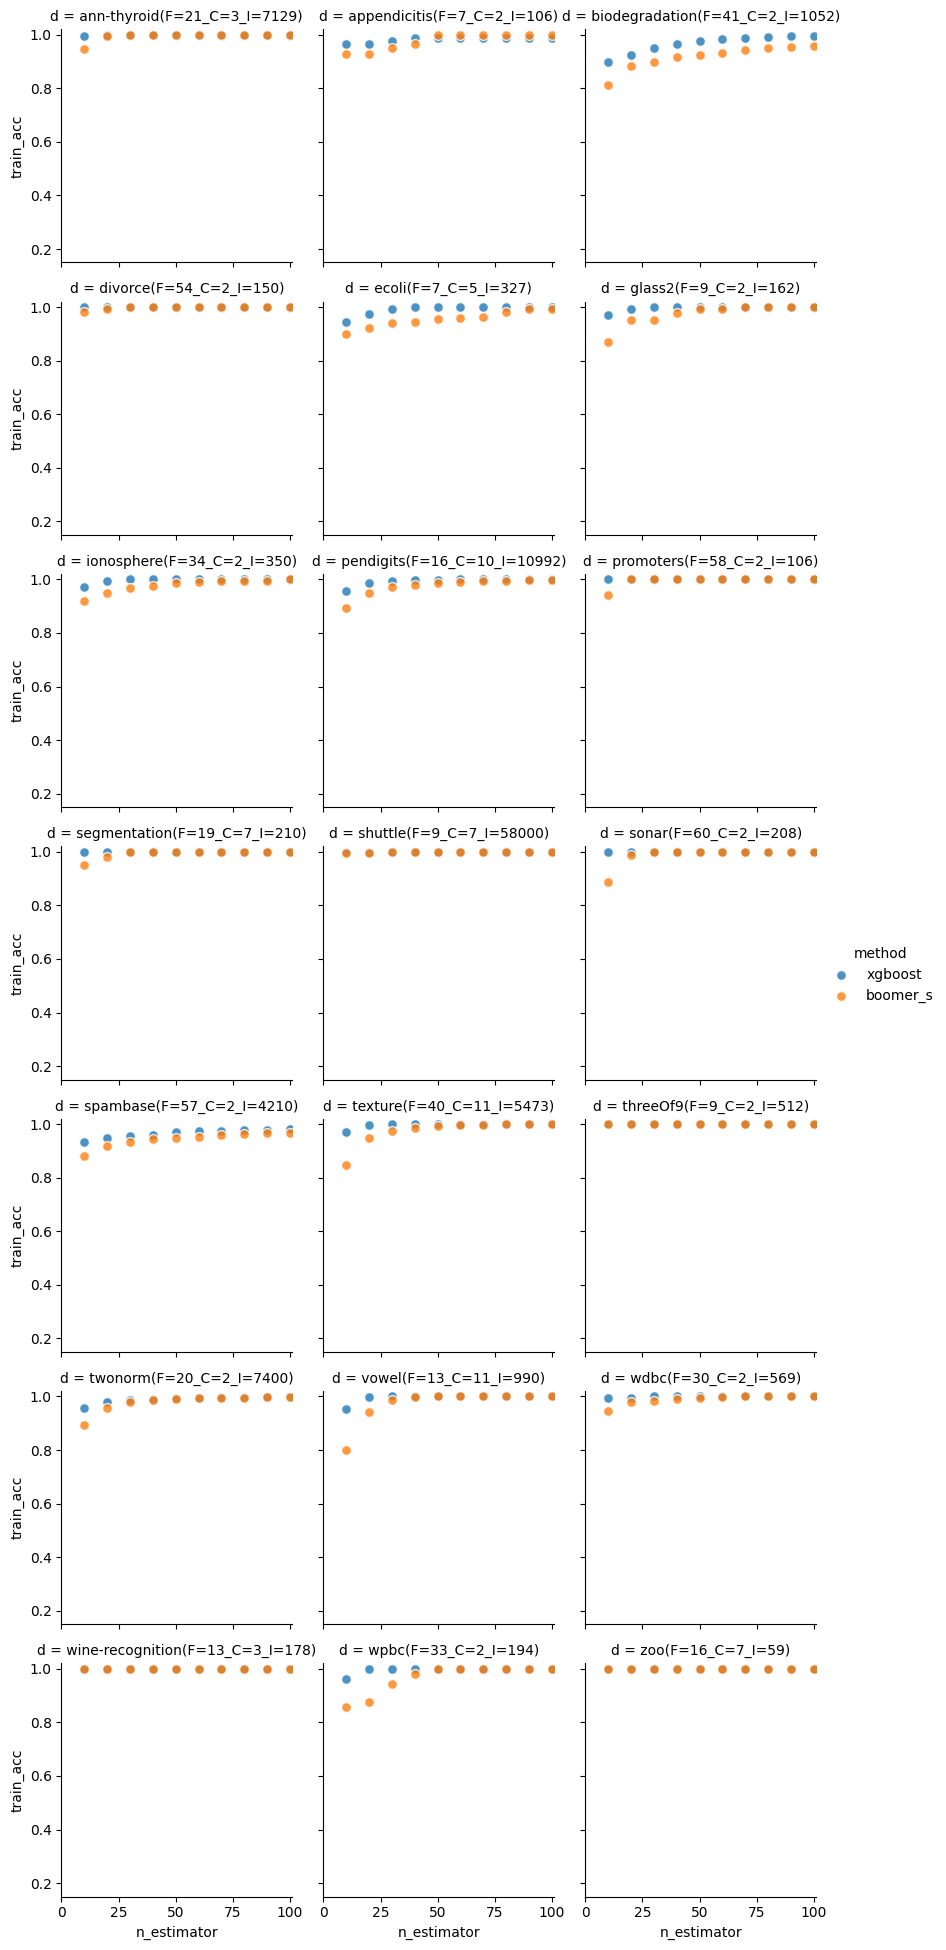

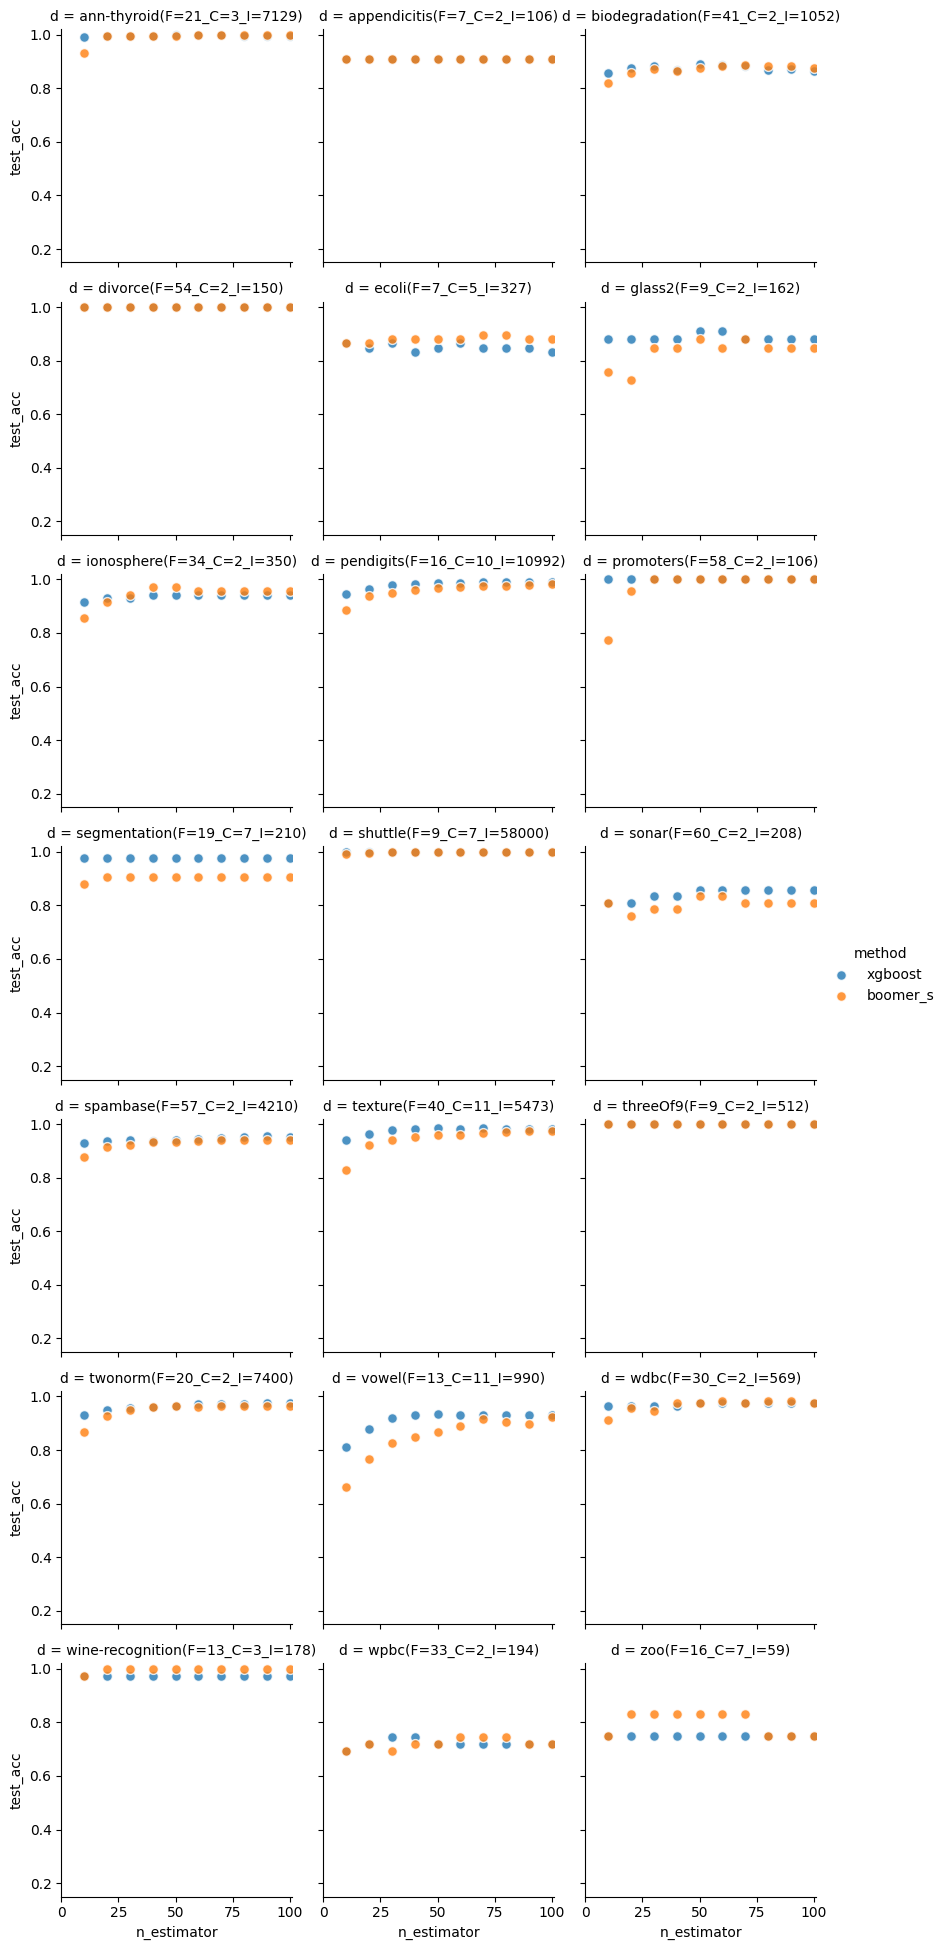

In [3]:
# considering the df with boomer_s
df_boomer_s['method'] = 'boomer_s'

# concat the two dataframe into one
df_xgboost_boomers = pd.concat([df_xgboost, df_boomer_s])

df_xgboost_boomers['dataset'] = df_xgboost_boomers.apply(add_dataset_info, axis='columns')
df_xgboost_boomers.rename(columns={'dataset': 'd'}, inplace=True)


# The scatter for presenting all training accuracy categorized by dataset
g2 = sns.FacetGrid(df_xgboost_boomers, col='d', col_wrap=3, xlim=(0, 101), ylim=(0.15, 1.02), hue='method', height=2.8)
g2.map(sns.scatterplot, 'n_estimator', 'train_acc', edgecolor="white", s=50, lw=1, alpha=.8)
g2.add_legend()
g2.savefig('./xgboost_boomer_s_train_acc.png')

# The scatter for presenting all testing accuracy categorized by dataset
g3 = sns.FacetGrid(df_xgboost_boomers, col='d', col_wrap=3, xlim=(0, 101), ylim=(0.15, 1.02), hue='method', height=2.8)
g3.map(sns.scatterplot, 'n_estimator', 'test_acc', edgecolor="white", s=50, lw=1, alpha=.8)
g3.add_legend()
g3.savefig('./xgboost_boomer_s_test_acc.png')

### 250926: preparing the Radar images to compare the prediction quality between BOOMER and XGBoost.

In [ ]:
## Trying the basic radar chart example
import plotly.graph_objects as go

categories = ['Hello','one','two',
              'thermal stability', 'device integration', 'end1', 'end2']
fig = go.Figure()
fig.add_trace(go.Scatterpolar(
      r=[1.23, 5, 2, 2, 4.2, 3.1, 3.2],
      theta=categories,
      fill='toself',
      fillcolor="#DF5916",
      line_color="#DF5916",
      name='Product A'
))
fig.add_trace(go.Scatterpolar(
    r=[4, 3, 2.5, 1, 2, 2.5, 2.8],
    theta=categories,
    fill='toself',
    fillcolor="#5E838F",
    line_color="#5E838F",
    name='Product B'
))
fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[1,6]
    )),
  showlegend=True
)
fig.show()

In [50]:
import plotly.express as px
df = px.data.wind()
fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma_r,
                    template="plotly_dark",)
fig.show()

print(df)
print(len(df['direction'].unique()))

    direction strength  frequency
0           N      0-1        0.5
1         NNE      0-1        0.6
2          NE      0-1        0.5
3         ENE      0-1        0.4
4           E      0-1        0.4
..        ...      ...        ...
123       WSW       6+        0.1
124         W       6+        0.9
125       WNW       6+        2.2
126        NW       6+        1.5
127       NNW       6+        0.2

[128 rows x 3 columns]
16
